In [69]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [45]:
warnings.filterwarnings("ignore")
dataset = pd.read_csv(r"C:\Users\hp\Desktop\14 Days 14 Models\model\FyntraCustomerData.csv")

In [46]:
dataset.head(3)

,Email,Address,Avatar,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505


In [47]:
dataset.drop(columns = ["Email","Address", "Avatar"], axis = 1, inplace = True) 

In [48]:
dataset.isnull().sum()


Avg_Session_Length      0
Time_on_App             0
Time_on_Website         0
Length_of_Membership    0
Yearly_Amount_Spent     0
dtype: int64

In [49]:
dataset.describe()

,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


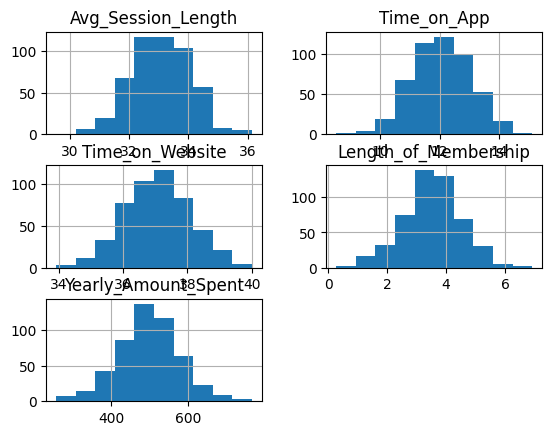

In [50]:
dataset.hist()
plt.show()

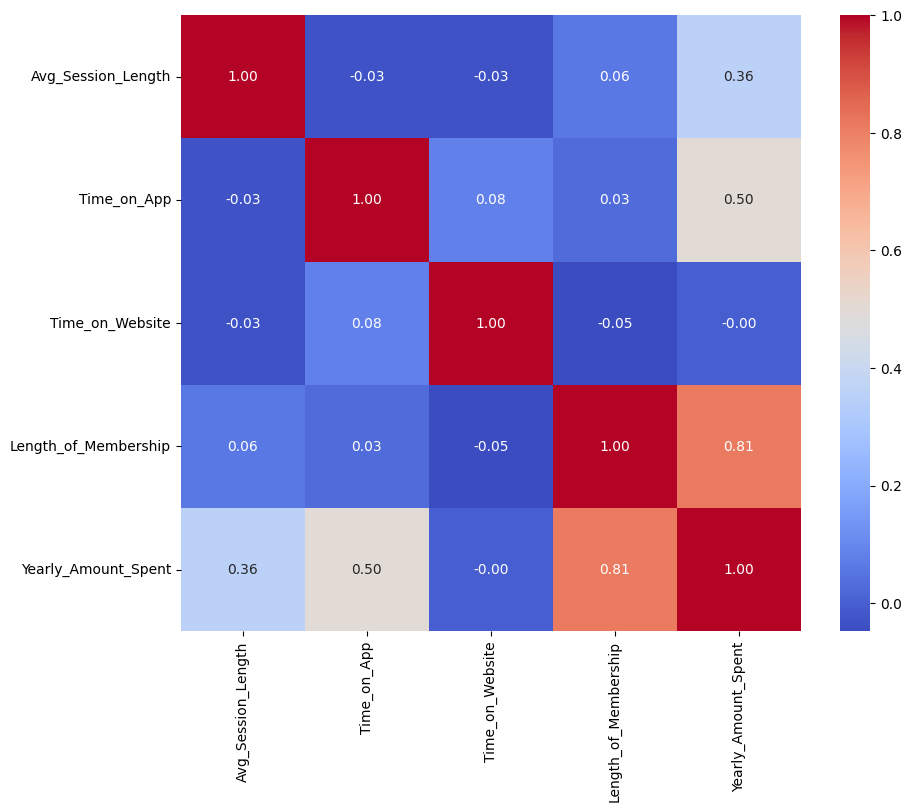

In [51]:
plt.figure(figsize=(10, 8))
dataset.corr()
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [52]:
X = dataset.drop("Yearly_Amount_Spent", axis = 1)
y = dataset["Yearly_Amount_Spent"]

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.20)

In [55]:
from sklearn.preprocessing import StandardScaler

In [ ]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)


In [61]:
# Model training

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [63]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
lr.score(X_test, y_test)*100

97.78130629248282

In [66]:
# Metrixes

y_pred = lr.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE: ", mse)

mae = mean_absolute_error(y_test, y_pred)
print("MAE: ", mae)

rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE: ", rmse)


MSE:  109.8637411521613
MAE:  8.558441887438093
RMSE:  10.481590583120546


In [70]:
residuals = np.min(y_test - y_pred)
residuals

np.float64(-30.123814200391053)

In [71]:
# Exporting the Model for streamlit app

import joblib

In [73]:
joblib.dump(lr, "model.pkl")

['model.pkl']